In [ ]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import PageBreak
from reportlab.platypus import Image

# ── Colour palette we'll reuse ────────────────────────────────────────────────
BLUE   = '#2166ac'
ORANGE = '#d6604d'

def export_real_estate_pdf(summary, graph_filename, filename):

    doc = SimpleDocTemplate(filename)
    styles = getSampleStyleSheet()
    elements = []

    # =====================================================
    # TITLE
    # =====================================================
    title = Paragraph(
        "REAL ESTATE MARKET REPORT - BELGIUM",
        styles["Title"]
    )
    elements.append(title)
    elements.append(Spacer(1, 15))

    intro = Paragraph(
        "This report summarizes the most and least expensive municipalities in Belgium, "
        "based on price per m², average price, and median price.",
        styles["BodyText"]
    )
    elements.append(intro)
    elements.append(Spacer(1, 20))


    # =========================
    # DASHBOARD IMAGE
    # =========================
    elements.append(Paragraph("<b>Visual Dashboard</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    try:
        img = Image(graph_filename)

        max_width = 400

        scale = max_width / img.imageWidth
        img.drawWidth = img.imageWidth * scale
        img.drawHeight = img.imageHeight * scale

        elements.append(img)
    except:
        elements.append(Paragraph("Dashboard image not found.", styles["Normal"]))

    # =====================================================
    # REGION TABLES
    # =====================================================
    elements.append(PageBreak())
    for _, row in summary.iterrows():

        region = row["region"].upper()

        elements.append(Paragraph(f"<b>{region}</b>", styles["Heading2"]))
        elements.append(Spacer(1, 10))

        table_data = [
            ["Metric", "Lowest", "Value", "Highest", "Value"],

            ["Price per m²",
             row["min_city_m2"],
             f"€{row['m2_min']:,.0f}/m²",
             row["max_city_m2"],
             f"€{row['m2_max']:,.0f}/m²"],

            ["Average Price",
             row["min_city_price"],
             f"€{row['price_min']:,.0f}",
             row["max_city_price"],
             f"€{row['price_max']:,.0f}"],

            ["Median Price",
             row["min_city_median"],
             f"€{row['median_min']:,.0f}",
             row["max_city_median"],
             f"€{row['median_max']:,.0f}"],
        ]

        table = Table(table_data)

        table.setStyle(TableStyle([
            ("BACKGROUND", (0,0), (-1,0), colors.grey),
            ("TEXTCOLOR", (0,0), (-1,0), colors.white),
            ("GRID", (0,0), (-1,-1), 0.5, colors.black),
            ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
            ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ]))

        elements.append(table)
        elements.append(Spacer(1, 15))

        # =================================================
        # INSIGHT TEXT (AUTO)
        # =================================================
        insight = f"""
        <b>Key Insight:</b><br/>
        In {region}, the highest price per m² is in
        <b>{row['max_city_m2']}</b>, while the lowest is
        <b>{row['min_city_m2']}</b>.<br/><br/>

        The most expensive municipality overall is
        <b>{row['max_city_price']}</b>, while the cheapest is
        <b>{row['min_city_price']}</b>.<br/><br/>

        This shows strong price inequality across municipalities in {region}.
        """

        elements.append(Paragraph(insight, styles["BodyText"]))
        elements.append(Spacer(1, 25))

    # =====================================================
    # FINAL BELGIUM SUMMARY
    # =====================================================
    belgium = summary[summary["region"].str.lower() == "belgium"].iloc[0]

    elements.append(Paragraph("<b>FINAL CONCLUSION</b>", styles["Heading1"]))
    elements.append(Spacer(1, 10))

    final_text = f"""
    • Most expensive municipality in Belgium:
    <b>{belgium['max_city_price']}</b> (€{belgium['price_max']:,.0f})<br/><br/>

    • Cheapest municipality in Belgium:
    <b>{belgium['min_city_price']}</b> (€{belgium['price_min']:,.0f})<br/><br/>

    • Highest price per m²:
    <b>{belgium['max_city_m2']}</b> (€{belgium['m2_max']:,.0f}/m²)<br/><br/>

    • Lowest price per m²:
    <b>{belgium['min_city_m2']}</b> (€{belgium['m2_min']:,.0f}/m²)<br/><br/>

    Belgium shows strong regional disparity between luxury and affordable municipalities.
    """

    elements.append(Paragraph(final_text, styles["BodyText"]))

    # =====================================================
    # BUILD PDF
    # =====================================================
    doc.build(elements)

    print(f"PDF saved: {filename}")

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# BELGIUM SUMMARY 
# =========================================================
def get_belgium_summary(df):

    city_stats = (
        df.groupby("city")
        .agg(
            mean_price=("price", "mean"),
            median_price=("price", "median"),
            total_price=("price", "sum"),
            total_surface=("livable_surface", "sum")
        )
        .reset_index()
    )

    city_stats["weighted_m2"] = np.where(
        city_stats["total_surface"] == 0,
        np.nan,
        city_stats["total_price"] / city_stats["total_surface"]
    )

    return pd.DataFrame([{
        "region": "Belgium",

        # -------------------------
        # GLOBAL STATS
        # -------------------------
        "mean_price": round(df["price"].mean()),
        "median_price": round(df["price"].median()),
        "mean_m2": round(df["price_per_m2"].mean()),

        # -------------------------
        # €/m²
        # -------------------------
        "min_city_m2": city_stats.loc[city_stats["weighted_m2"].idxmin(), "city"],
        "m2_min": round(city_stats["weighted_m2"].min()),

        "max_city_m2": city_stats.loc[city_stats["weighted_m2"].idxmax(), "city"],
        "m2_max": round(city_stats["weighted_m2"].max()),

        # -------------------------
        # PRICE (mean)
        # -------------------------
        "min_city_price": city_stats.loc[city_stats["mean_price"].idxmin(), "city"],
        "price_min": round(city_stats["mean_price"].min()),

        "max_city_price": city_stats.loc[city_stats["mean_price"].idxmax(), "city"],
        "price_max": round(city_stats["mean_price"].max()),

        # -------------------------
        # MEDIAN
        # -------------------------
        "min_city_median": city_stats.loc[city_stats["median_price"].idxmin(), "city"],
        "median_min": round(city_stats["median_price"].min()),

        "max_city_median": city_stats.loc[city_stats["median_price"].idxmax(), "city"],
        "median_max": round(city_stats["median_price"].max()),
    }])


# =========================================================
# MAIN
# =========================================================
def draw_dashboard(df):

    # -------------------------
    # REGION LEVEL
    # -------------------------
    summary = df.groupby("region", as_index=False).agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        mean_m2=("price_per_m2", "mean")
    )

    # -------------------------
    # CITY LEVEL
    # -------------------------
    city_stats = df.groupby(["region", "city"]).agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        total_price=("price", "sum"),
        total_surface=("livable_surface", "sum")
    ).reset_index()

    city_stats["weighted_m2"] = np.where(
        city_stats["total_surface"] == 0,
        np.nan,
        city_stats["total_price"] / city_stats["total_surface"]
    )

    # =========================================================
    # MIN / MAX METRICS
    # =========================================================
    w_min = city_stats.loc[city_stats.groupby("region")["weighted_m2"].idxmin()][["region", "city", "weighted_m2"]]
    w_max = city_stats.loc[city_stats.groupby("region")["weighted_m2"].idxmax()][["region", "city", "weighted_m2"]]

    w_min = w_min.rename(columns={"city": "min_city_m2", "weighted_m2": "m2_min"})
    w_max = w_max.rename(columns={"city": "max_city_m2", "weighted_m2": "m2_max"})

    p_min = city_stats.loc[city_stats.groupby("region")["mean_price"].idxmin()][["region", "city", "mean_price"]]
    p_max = city_stats.loc[city_stats.groupby("region")["mean_price"].idxmax()][["region", "city", "mean_price"]]

    p_min = p_min.rename(columns={"city": "min_city_price", "mean_price": "price_min"})
    p_max = p_max.rename(columns={"city": "max_city_price", "mean_price": "price_max"})

    m_min = city_stats.loc[city_stats.groupby("region")["median_price"].idxmin()][["region", "city", "median_price"]]
    m_max = city_stats.loc[city_stats.groupby("region")["median_price"].idxmax()][["region", "city", "median_price"]]

    m_min = m_min.rename(columns={"city": "min_city_median", "median_price": "median_min"})
    m_max = m_max.rename(columns={"city": "max_city_median", "median_price": "median_max"})

    # =========================================================
    # MERGE
    # =========================================================
    summary = summary.merge(w_min, on="region").merge(w_max, on="region")
    summary = summary.merge(p_min, on="region").merge(p_max, on="region")
    summary = summary.merge(m_min, on="region").merge(m_max, on="region")

    # -------------------------
    # ADD BELGIUM SAFE
    # -------------------------
    belgium = get_belgium_summary(df)

    for col in summary.columns:
        if col not in belgium.columns:
            belgium[col] = np.nan

    belgium = belgium[summary.columns]

    summary = pd.concat([summary, belgium], ignore_index=True)

    summary = summary.sort_values("region").reset_index(drop=True)

    print(summary)

    # =========================================================
    # PLOT
    # =========================================================
    x = np.arange(len(summary))
    width = 0.35

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    fig.subplots_adjust(
        top=0.92,
        bottom=0.08,
        hspace=0.3
    )

    # -------------------------
    # 1 €/m²
    # -------------------------
    axes[0].bar(x - width/2, summary["m2_min"], width, label="Weighted €/m² - Min City", color=ORANGE)
    axes[0].bar(x + width/2, summary["m2_max"], width, label="Weighted €/m² - Max City", color=BLUE)
    axes[0].plot(x, summary["mean_m2"], marker="o", label="Weighted €/m² (Mean)", color="red")

    axes[0].set_title("Weighted Average Price €/m² distribution with Min/Max Cities")
    axes[0].set_ylabel("€/m²")
    
    for i in range(len(summary)):
            
        # label min city
        axes[0].text(
            x[i]-width/2,
            summary["m2_min"][i],
            summary["min_city_m2"][i],
            ha="center",
            fontsize=8
        )

        # label max city
        axes[0].text(
            x[i]+width/2,
            summary["m2_max"][i],
            summary["max_city_m2"][i],
            ha="center",
            fontsize=8
        )

        # label line chart (MEAN)
        axes[0].text(
            x[i],
            summary["mean_m2"][i],
            f"{summary['mean_m2'][i]:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="black"
        )

    # -------------------------
    # 2 Mean price
    # -------------------------
    axes[1].bar(x - width/2, summary["price_min"], width, label="Mean € - Min City", color=ORANGE)
    axes[1].bar(x + width/2, summary["price_max"], width, label="Mean € - Max City", color=BLUE)
    axes[1].plot(x, summary["mean_price"], marker="o", label="Mean €", color="red")

    axes[1].set_title("Mean Price € distribution with Min/Max Cities")
    axes[1].set_ylabel("€")

    for i in range(len(summary)):
        # label min city
        axes[1].text(
            x[i]-width/2,
            summary["price_min"][i],
            summary["min_city_price"][i],
            ha="center",
            fontsize=8
        )

        # label max city
        axes[1].text(
            x[i]+width/2,
            summary["price_max"][i],
            summary["max_city_price"][i],
            ha="center",
            fontsize=8
        )

        # label line chart (MEAN PRICE)
        axes[1].text(
            x[i],
            summary["mean_price"][i],
            f"{summary['mean_price'][i]:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="black"
        )

    # -------------------------
    # 3 Median price
    # -------------------------
    axes[2].bar(x - width/2, summary["median_min"], width, label="Median € - Min City", color=ORANGE)
    axes[2].bar(x + width/2, summary["median_max"], width, label="Median € - Max City", color=BLUE)
    axes[2].plot(x, summary["median_price"], marker="o", label="Median €", color="red")

    axes[2].set_title("Median Price € distribution with Min/Max Cities")
    axes[2].set_ylabel("€")

    for i in range(len(summary)):
        # label min city
        axes[2].text(
            x[i]-width/2,
            summary["median_min"][i],
            summary["min_city_median"][i],
            ha="center",
            fontsize=8
        )

        # label max city
        axes[2].text(
            x[i]+width/2,
            summary["median_max"][i],
            summary["max_city_median"][i],
            ha="center",
            fontsize=8
        )

        # label line chart (MEDIAN PRICE)
        axes[2].text(
            x[i],
            summary["median_price"][i],
            f"{summary['median_price'][i]:,.0f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="black"
        )

    # =========================================================
    # FIX X-AXIS (REGION LABELS)
    # =========================================================
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(summary["region"], rotation=0)
        # ax.set_xlabel("Region")
        
        ax.margins(y=0.2)
        ax.legend(
            loc="upper left",
            bbox_to_anchor=(1, 1),
            frameon=True
        )

    plt.savefig("min_max_price_cities_of_regions.png", dpi=300)
    plt.show()

    export_real_estate_pdf(summary, "min_max_price_cities_of_regions.png", "min_max_price_cities_of_regions_report.pdf")

In [152]:

GEO_DATA = {
    "bruxelles": {
        "name": "Bruxelles-Capitale", 
        "provinces": ["brussels"]},
    "flandre": {
        "name": "Flandre", 
        "provinces": [
            "antwerp", 
            "limburg", 
            "east-flanders", 
            "vlaams-brabant", 
            "west-flanders"]},
    "wallonie": {
        "name": "Wallonie", 
        "provinces": [
            "hainaut", 
            "liege", 
            "luxembourg", 
            "namur", 
            "brabant-wallon"]}
}

def clean_data(df):
    df = df.copy()

    # 1. convert FIRST (quan trọng)
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    # 2. remove missing
    df = df.dropna(subset=["price", "livable_surface", "province"])

    # 3. remove invalid values
    df = df[(df["price"] > 0) & (df["livable_surface"] > 10)]

    # 4. compute feature
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    # 6. normalize text
    df["province"] = df["province"].str.lower()
    df = df.groupby("city").filter(lambda x: len(x) >= 10)
    return df

def province_to_region(df):
    province_to_region = {
        province.lower(): region
        for region, info in GEO_DATA.items()
        for province in info["provinces"]
    }
    df["region"] = df["province"].map(province_to_region)
    return df


def compute_metrics(df):
    # Weighted price per m² (MOST IMPORTANT - market truth)
    weighted = (
        df.groupby("region")[["price", "livable_surface"]]
        .sum()
        .eval("price / livable_surface")
        .sort_values(ascending=False)
    )

    count = df["region"].value_counts()


    return weighted, count

      region     mean_price  median_price      mean_m2          min_city_m2  \
0    Belgium  484417.000000      299000.0  3161.000000               Mettet   
1  bruxelles  755946.531532      390757.5  3982.620783  Sint-Jans-Molenbeek   
2    flandre  469359.952060      300000.0  3146.973860               Wervik   
3   wallonie  402269.345137      270000.0  2880.324529               Mettet   

        m2_min          max_city_m2        m2_max min_city_price  \
0   730.000000             Cheratte  11381.000000       Blaimont   
1  2280.842298  Sint-Pieters-Woluwe   4984.066236     Koekelberg   
2  1262.162162         Knokke-Heist   9819.704786    Middelkerke   
3   729.653882             Cheratte  11381.102136       Blaimont   

       price_min       max_city_price     price_max      min_city_median  \
0   89714.000000  Sint-Pieters-Woluwe  1.423236e+06             Blaimont   
1  199088.368421  Sint-Pieters-Woluwe  1.423236e+06  Sint-Joost-ten-Node   
2  151491.666667         Knokke-Hei

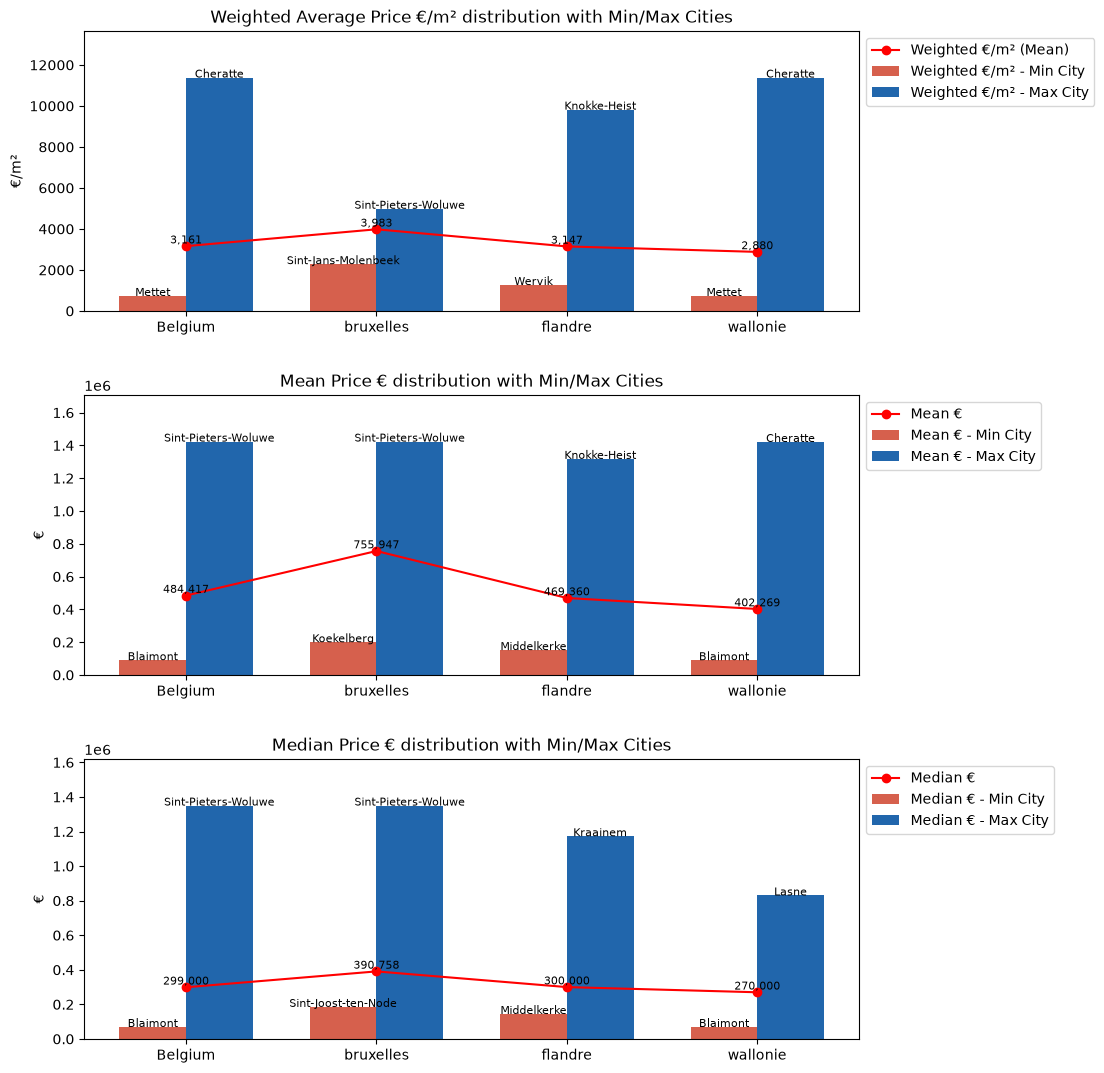

PDF saved: min_max_price_cities_of_regions_report.pdf


In [153]:
df = pd.read_json("clean_dataframe_fixed.json")

df_clean = clean_data(df)
df_clean = province_to_region(df_clean) 
weighted, count = compute_metrics(df_clean)
draw_dashboard(df_clean)